# Differential expression analysis

**Summary.** This notebook runs differential expression (DE) analysis for the whole brain perturbation screen and produces manuscript figures and supplementary tables.

- **Data:** Loads `WB8588_screen_gex_filtered_reassigned_final_all_qc_filtered.zarr`. DE is computed per **cell type** (`group_name`) with **Non_target** as control.
- **DE method:** Wilcoxon rank-sum test per gene per (perturbation × cell type) via `run_wilcoxon_de_per_cell_type`. Significant hits: FDR &lt; 0.05, |log₂FC| &gt; 0.5, ≥ 20 cells per group. Gene-level stats (fraction expressed, mean expression) are added with `compute_gene_stats`. DE genes with FDR > 0.1 are in Data S4A.
- **Summaries:** `summarize_de_genes_per_condition` builds condition-level summaries (number of DE genes, mean |LFC|).
- **Figure S6 B:** (1) heatmap of **potency** (number of DE genes per gene × cell type), (2) heatmap of **magnitude** (mean absolute LFC). Rows = perturbed genes (grouped by functional group, sorted by potency); columns = cell types (hierarchically clustered). Group dividers and labels are drawn on the heatmaps.
- **Data S4B:** Exports `Supplementary_Table_Perturbation_Analysis.csv` with Gene, Functional Group, Total DE Genes (Potency), Mean Abs LFC (Magnitude), and Top 3 Affected Cell Types, sorted by functional group and potency.

## Differential expression analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("/workspace/wholebrainperturbseq")

In [ ]:
import os
import polars as pl

import pandas as pd
import numpy as np
import anndata as ad

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Setting up global variables:

In [4]:
LFC_THRESHOLD = 0.5
PVAL_THRESHOLD = 0.05
DE_CELL_TYPE_COL = "group_name"
TARGET_GENE_COL = "gene_target"
MIN_CELLS = 20

In [ ]:
MANUSCRIPT_DIR = "/data/perturbai/WB8588_screen/manuscript"

OUT_DIR = f"{MANUSCRIPT_DIR}/analysis/de_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

DATA_DIR = f"{MANUSCRIPT_DIR}/data/"
DATA_FILENAME = "WB8588_screen_gex_filtered_reassigned_final_all_qc_filtered.zarr"
DATA_PATH = os.path.join(DATA_DIR, DATA_FILENAME)

### Loading data:

In [8]:
adata = ad.read_zarr(DATA_PATH)

### Computing DE genes with Wilcoxon single cell test:

DE genes per cell type:

Data S4A tab "wilcoxon_de_results_padj_0.1" contains DE genes with pvals_adj < 0.1 computed with Wilcoxon rank-sum test below: 

In [ ]:
from analysis_lib.deg_utils import run_wilcoxon_de_per_cell_type
exp_name = ""

if os.path.exists(f"{OUT_DIR}/wilcoxon/{DE_CELL_TYPE_COL}/wilcoxon_de_results_{DE_CELL_TYPE_COL}{exp_name}.parquet"):
    df_full = pl.read_parquet(f"{OUT_DIR}/wilcoxon/{DE_CELL_TYPE_COL}/wilcoxon_de_results_{DE_CELL_TYPE_COL}{exp_name}.parquet")
    df_sig = df_full.filter((pl.col("pvals_adj") < PVAL_THRESHOLD) & (pl.col("n_pert_matched") >= MIN_CELLS) & (pl.col("logfoldchanges").abs() > LFC_THRESHOLD))
    df_sig = df_sig.to_pandas()
else:
    df_full = run_wilcoxon_de_per_cell_type(
            adata,
            labels=TARGET_GENE_COL,
            subclass_col=DE_CELL_TYPE_COL,
            control_labels=["Non_target"],
            min_cells_per_group=20,
            n_jobs=128,
            match_libsize=False,
            out_dir=None
        )
    df_full.to_parquet(f"{OUT_DIR}/wilcoxon/{DE_CELL_TYPE_COL}/wilcoxon_de_results_{DE_CELL_TYPE_COL}{exp_name}.parquet")
    df_sig = df_full[(df_full["pvals_adj"] < PVAL_THRESHOLD) & (df_full["n_pert_matched"] >= MIN_CELLS) & (df_full["logfoldchanges"].abs() > LFC_THRESHOLD)]

In [14]:
from analysis_lib.deg_utils import compute_gene_stats
df_sig = compute_gene_stats(df_sig, adata, TARGET_GENE_COL, DE_CELL_TYPE_COL, verbose=True)

Computing fract. expressed & mean expr.: 100%|██████████| 3303/3303 [00:40<00:00, 82.40it/s] 


In [16]:
print(f"Number of significant DEGs (FDR < 0.05 & |LFC| > {LFC_THRESHOLD}) {len(df_sig)}")

Number of significant DEGs (FDR < 0.05 & |LFC| > 0.5) 62715


In [20]:
dropout_threshold = 0.8
print(f"Number of DEGs with dropout of {dropout_threshold*100}% or more in control AND perturb: {len(df_sig[(df_sig['frac_expr_control'] < (1 - dropout_threshold)) & (df_sig['frac_expr_perturb'] < (1 - dropout_threshold))])}")

Number of DEGs with dropout of 80.0% or more in control AND perturb: 175


 ### Data visualization

Number of conditions with at least  5  DE genes:  631
Number of unique target genes:  171
Number of unique group names:  22


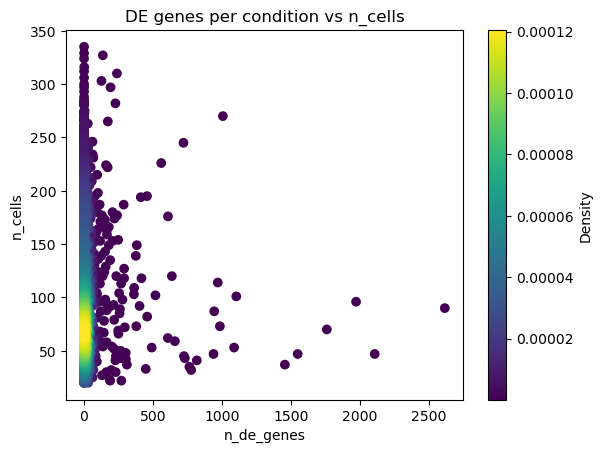

In [23]:
from analysis_lib.plot_utils import summarize_de_genes_per_condition
results_df, _, _, _ = summarize_de_genes_per_condition(
    df_sig, 
    min_de_genes=5, 
    lfc_threshold=LFC_THRESHOLD, 
    plot=True,
    verbose=True,
    target_gene_col=TARGET_GENE_COL,
)

These group definitions will be refined later:

In [ ]:
# Define functional groups (Genes appear only once here)
gene_groups = {
    "Chromatin & Epigenetic": [
        'Adnp', 'Arid2', 'Atrx', 'Bap1', 'Bptf', 'Brd4', 'Chd2', 'Chd4', 'Chd8', 
        'Ctcf', 'Gatad1', 'Kansl1', 'Kdm5c', 'Kmt2a', 'Kmt2b', 'Kmt2d', 'Mecp2', 
        'Nipbl', 'Nsd1', 'Phf12', 'Prdm10', 'Setd1a', 'Setdb1', 'Sin3a', 'Smarcb1', 
        'Smarcc2', 'Trrap', 'Yy1', 'Zbtb11', 'Zbtb7a'
    ],
    "RNA & Transcription": [
        'Atf2', 'Cdc40', 'Celf2', 'Cic', 'Creb1', 'Ddx23', 'Ddx39b', 'Dhx9', 'E2f4', 
        'Eef2', 'Fus', 'Gtf2i', 'Hnrnpc', 'Hnrnpu', 'Klf9', 'Matr3', 'Max', 'Mef2c', 
        'Myt1l', 'Nrf1', 'Prpf6', 'Rbfox1', 'Rnpc3', 'Rrn3', 'Snrnp70', 'Srsf1', 
        'Srrm2', 'Tardbp', 'Tbr1', 'Tcf7l2', 'Thap1', 'Thap11', 'Thoc1', 'Thoc2', 
        'U2af2', 'Xrn1', 'Ylpm1', 'Zeb1', 'Zfx', 'Zmym2', 'Zmynd8'
    ],
    "Synaptic & Structural": [
        'Actb', 'Ank3', 'Atp1a3', 'Dctn1', 'Dnm1l', 'Dync1h1', 'Grin1', 'Grin2a', 
        'Grin2b', 'Kcnb1', 'Slc12a5', 'Sp4', 'Stxbp1', 'Tbcd', 'Tuba1a'
    ],
    "Proteostasis & Growth": [
        'Depdc5', 'Eif4e', 'Elp1', 'Elp2', 'Hspa5', 'Hspa9', 'Huwe1', 'Manf', 
        'Marchf6', 'Mib1', 'Naa15', 'Naa20', 'Pomp', 'Psmb4', 'Psmc1', 'Psmc5', 
        'Pten', 'Rb1', 'Rb1cc1', 'Sec63', 'Tsc1', 'Tsc2', 'Uba5', 'Ufc1', 'Ufsp2', 
        'Vps37a', 'Wac', 'Wdr26'
    ],
    "Vesicle & Transport": [
        'Ap2m1', 'Ap2s1', 'Atp6v0c', 'Atp6v1b2', 'B9d1', 'Caml', 'Chp1', 'Cltc', 
        'Pitpna', 'Rab7', 'Sec31a', 'Tnpo3', 'Vps35', 'Vps54', 'Xpo1'
    ],
    "Signaling & Metabolism": [
        'Apc', 'Ascc3', 'Atp2a2', 'Atp2b1', 'Atxn1', 'Atxn10', 'Bmal1', 'Camta1', 
        'Cdk13', 'Csnk2b', 'Ctbp1', 'Ctnnb1', 'Dhdds', 'Esrra', 'Gfpt1', 'Gigyf2', 
        'Htt', 'Nr1d1', 'Ogt', 'Opa1', 'Pcyt2', 'Ppp2r1a', 'Ppp3r1', 'Prox1', 
        'Ranbp2', 'Rora', 'Ski', 'Srebf2', 'Supt16', 'Txndc15'
    ]
}

# 1. Create mapping
gene_to_group = {gene: grp for grp, genes in gene_groups.items() for gene in genes}

# 2. Define the explicit sort order for the Y-axis
group_order = [
    "Chromatin & Epigenetic",
    "RNA & Transcription",
    "Synaptic & Structural",
    "Proteostasis & Growth",
    "Vesicle & Transport",
    "Signaling & Metabolism",
    "Other"
]

In [25]:
n_de_genes_threshold = 5

df_sig = df_sig[df_sig["logfoldchanges"].abs() >= LFC_THRESHOLD]

results_df, n_conditions, n_target_genes, n_group_names = summarize_de_genes_per_condition(
    df_sig,
    min_de_genes=n_de_genes_threshold,
    lfc_threshold=LFC_THRESHOLD,
    plot=False,
    verbose=False,
    target_gene_col=TARGET_GENE_COL,
    )
    
results_df = results_df[results_df["n_de_genes"] >= n_de_genes_threshold]

# 1. Prepare data

pivot_df = results_df.pivot(index=TARGET_GENE_COL, columns=DE_CELL_TYPE_COL, values="n_de_genes").fillna(0)

# --- Cap the data BEFORE clustering for n_de_genes ---
de_genes_cap = 100
capped_df = pivot_df.clip(upper=de_genes_cap)

# Filter for active genes (those having > 0 DEGs after potential thresholding)
filtered_df = capped_df[capped_df.max(axis=1) > 0]

# 1b. Prepare data for mean_abs_lfc
pivot_lfc_df = results_df.pivot(index=TARGET_GENE_COL, columns=DE_CELL_TYPE_COL, values="mean_abs_lfc").fillna(0)

# Use same order and filter as DE gene heatmap for row/col
pivot_lfc_df = pivot_lfc_df.loc[filtered_df.index, filtered_df.columns]
mean_lfc_cap = 2.0
filtered_lfc_df = pivot_lfc_df.clip(upper=mean_lfc_cap)

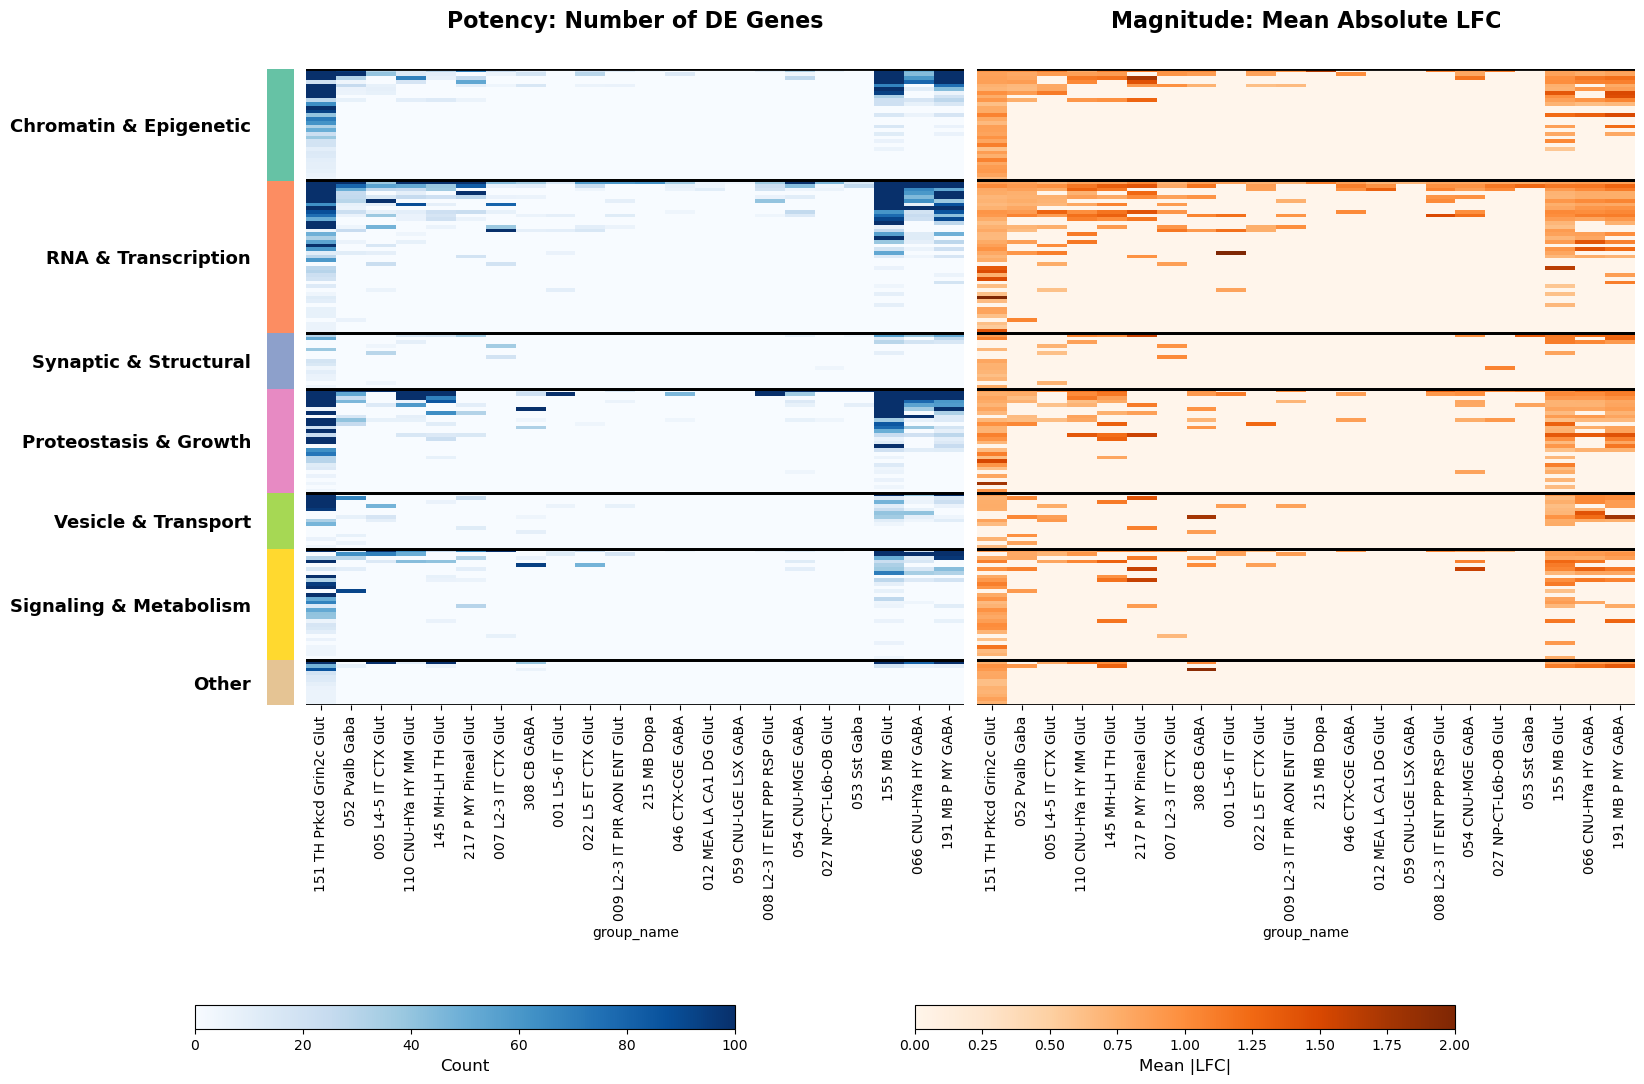

In [ ]:
# Figure S6 B

from scipy.cluster import hierarchy

# 1. Prepare and Sort Rows by Group and Potency
temp_df = filtered_df.copy()
temp_df['group'] = temp_df.index.map(lambda x: gene_to_group.get(x, "Other"))
temp_df['group'] = pd.Categorical(temp_df['group'], categories=group_order, ordered=True)
temp_df['total_potency'] = temp_df.sum(axis=1, numeric_only=True)
temp_df = temp_df.sort_values(by=['group', 'total_potency'], ascending=[True, False])

# 2. Reorder initial data based on sorted rows
filtered_df_plot = filtered_df.loc[temp_df.index]
filtered_lfc_plot = filtered_lfc_df.loc[temp_df.index]

# 3. Hierarchical Clustering on Columns (Cell Types)
# We cluster based on the Potency (DE Gene Count)
col_linkage = hierarchy.linkage(filtered_df_plot.T.fillna(0), method="average", metric="euclidean")
col_dendro = hierarchy.dendrogram(col_linkage, no_plot=True)
col_order_names = filtered_df_plot.columns[col_dendro["leaves"]]

# Final reordering of both plotting DataFrames
filtered_df_plot = filtered_df_plot[col_order_names]
filtered_lfc_plot = filtered_lfc_plot[col_order_names]

# 4. Setup Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 12), 
                         gridspec_kw={"width_ratios": [0.04, 1, 1], "wspace": 0.03})

# --- AX 0: Group Color Strip ---
ax_col = axes[0]
unique_groups = temp_df['group'].unique()
colors = sns.color_palette("Set2", len(unique_groups))
group_color_dict = dict(zip(unique_groups, colors))
col_data = np.array([group_color_dict[g] for g in temp_df['group']]).reshape(-1, 1, 3)
ax_col.imshow(col_data, aspect='auto')
ax_col.set_xticks([]); ax_col.set_yticks([]); ax_col.set_ylabel("")
for spine in ax_col.spines.values(): spine.set_visible(False)

# --- AX 1 & 2: Heatmaps ---
sns.heatmap(filtered_df_plot, ax=axes[1], cmap="Blues", cbar=False, 
            vmin=0, vmax=de_genes_cap, yticklabels=False, xticklabels=True)
axes[1].set_ylabel("")

sns.heatmap(filtered_lfc_plot, ax=axes[2], cmap="Oranges", cbar=False, 
            vmin=0, vmax=mean_lfc_cap, yticklabels=False, xticklabels=True)
axes[2].set_ylabel("")

# --- 5. Add Dividers and Centered Group Labels ---
current_pos = 0
for group in unique_groups:
    group_size = len(temp_df[temp_df['group'] == group])
    for ax in [axes[1], axes[2]]:
        ax.axhline(current_pos, color='black', lw=2, zorder=10)
        ax.axhline(current_pos + group_size, color='black', lw=2, zorder=10)
    
    y_center = current_pos + (group_size / 2)
    ax_col.text(-0.6, y_center, group, va='center', ha='right', 
                fontsize=13, weight='bold', transform=ax_col.get_yaxis_transform())
    current_pos += group_size

# Titles
axes[1].set_title("Potency: Number of DE Genes", fontsize=16, weight='bold', pad=30)
axes[2].set_title("Magnitude: Mean Absolute LFC", fontsize=16, weight='bold', pad=30)

# --- 6. Horizontal Legends ---
cax0 = fig.add_axes([0.18, 0.08, 0.3, 0.02])
cb0 = fig.colorbar(axes[1].collections[0], cax=cax0, orientation='horizontal')
cb0.set_label('Count', fontsize=12)

cax1 = fig.add_axes([0.58, 0.08, 0.3, 0.02])
cb1 = fig.colorbar(axes[2].collections[0], cax=cax1, orientation='horizontal')
cb1.set_label('Mean |LFC|', fontsize=12)

plt.subplots_adjust(left=0.22, right=0.98, bottom=0.35, top=0.88)
plt.show()

In [ ]:
# Data S4B tab "Table S7. Perturbation Analysis"

gene_metadata = []
for gene in filtered_df.index:
    group = gene_to_group.get(gene, "Other")
    
    # Calculate global metrics
    potency = filtered_df.loc[gene].sum()
    magnitude = filtered_lfc_df.loc[gene].mean()
    
    # Identify top 3 most affected cell types (columns with highest DE count)
    top_cells = filtered_df.loc[gene].sort_values(ascending=False).head(3)
    top_cell_names = ", ".join([f"{cell} ({int(val)})" for cell, val in top_cells.items() if val > 0])
    
    gene_metadata.append({
        "Gene": gene,
        "Functional Group": group,
        "Total DE Genes (Potency)": int(potency),
        "Mean Abs LFC (Magnitude)": round(magnitude, 3),
        "Top 3 Affected Cell Types": top_cell_names
    })

# 2. Create DataFrame and Sort
supp_table = pd.DataFrame(gene_metadata)

# Sort the table to match your heatmap order
supp_table['Functional Group'] = pd.Categorical(
    supp_table['Functional Group'], 
    categories=group_order, 
    ordered=True
)
supp_table = supp_table.sort_values(
    by=['Functional Group', 'Total DE Genes (Potency)'], 
    ascending=[True, False]
)

# 3. Export to CSV
supp_table.to_csv("Supplementary_Table_Perturbation_Analysis.csv", index=False)

print(f"Table generated with {len(supp_table)} genes across {len(unique_groups)} groups.")

Table generated with 171 genes across 7 groups.


In [30]:
supp_table.head()

,Gene,Functional Group,Total DE Genes (Potency),Mean Abs LFC (Magnitude),Top 3 Affected Cell Types
163,Zbtb7a,Chromatin & Epigenetic,713,0.786,"191 MB P MY GABA (100), 151 TH Prkcd Grin2c Gl..."
118,Sin3a,Chromatin & Epigenetic,580,0.506,"191 MB P MY GABA (100), 052 Pvalb Gaba (100), ..."
116,Setd1a,Chromatin & Epigenetic,521,0.465,"191 MB P MY GABA (100), 151 TH Prkcd Grin2c Gl..."
67,Kansl1,Chromatin & Epigenetic,374,0.334,"155 MB Glut (100), 191 MB P MY GABA (100), 066..."
161,Yy1,Chromatin & Epigenetic,321,0.345,"151 TH Prkcd Grin2c Glut (100), 191 MB P MY GA..."
